# Bài 1: U-Net — vai trò của Skip Connection

Tự xây dựng U-Net bằng PyTorch, huấn luyện trên Oxford-IIIT Pet và so sánh với phiên bản không dùng skip connection. Trọng tâm là encoder, decoder, down/up-sampling và cách skip connection phục hồi thông tin không gian.

**Quy trình:** hoàn thành mọi cell `TODO`, chạy notebook từ trên xuống, kiểm tra shape, train hai model, rồi dùng kết quả thật để hoàn thiện nhận xét cuối bài.


## 1. Setup


In [1]:
!pip install -q torch torchvision matplotlib pandas pillow tqdm

In [2]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm

In [3]:
# =========================================================
# CẤU HÌNH
# =========================================================
# Chọn nơi lưu dataset theo môi trường chạy:
# - Google Colab  -> lưu trên Google Drive để tránh phải tải lại dataset.
# - Kaggle        -> lưu trong /kaggle/working.
# - Jupyter local -> lưu trong thư mục ./data.

IN_COLAB = "COLAB_RELEASE_TAG" in __import__("os").environ
IN_KAGGLE = Path("/kaggle/working").exists()

if IN_COLAB:
    try:
        from google.colab import drive

        drive.mount("/content/drive")
        DATA_ROOT = "/content/drive/MyDrive/datasets/OxfordIIITPet"
    except (NotImplementedError, RuntimeError):
        print("Không thể mount Google Drive. Dataset sẽ được lưu trong /content/data.")
        DATA_ROOT = "/content/data/OxfordIIITPet"

elif IN_KAGGLE:
    DATA_ROOT = "/kaggle/working/datasets/OxfordIIITPet"

else:
    DATA_ROOT = "./data/OxfordIIITPet"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 3  # pet / background / border
SEED = 42
NUM_EPOCHS = 10  # Có thể tăng để mô hình học tốt hơn.
LEARNING_RATE = 1e-3
NUM_WORKERS = 0

Mounted at /content/drive


In [4]:
# Cố định seed để kết quả dễ tái lập.
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")

Device: cuda


## 2. Dataset và preprocessing

Mask trimap được resize bằng nearest-neighbor và shift từ `{1,2,3}` về `{0,1,2}` trong code cung cấp sẵn.


In [5]:
# =========================================================
# DATASET VÀ DATALOADER
# =========================================================

# Mean và độ lệch chuẩn của ImageNet.
# Dùng để chuẩn hóa ảnh theo ImageNet.
# Notebook DeepLabV3 dùng ResNet18 pretrained trên ImageNet,
# Hai notebook dùng cùng cách chuẩn hóa để dễ so sánh.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class PetSegmentationDataset(Dataset):
    """
    Dataset wrapper cho Oxford-IIIT Pet.

    Mỗi phần tử trả về:
        image: Tensor [3, H, W]
        mask : Tensor [H, W]

    Ảnh và mask luôn được resize về cùng IMAGE_SIZE.
    """

    def __init__(self, subset, image_size):
        self.subset = subset
        self.image_size = image_size

    def __len__(self):
        # Trả về số mẫu trong tập dữ liệu.
        return len(self.subset)

    def __getitem__(self, index):
        # Lấy ảnh và mask tương ứng.
        # Ảnh đầu vào có ba kênh RGB.
        # Mask chứa nhãn segmentation.
        image, mask = self.subset[index]

        # Resize ảnh về kích thước cố định.
        # Nội suy bilinear giúp ảnh RGB mượt hơn.
        image = TF.resize(
            image,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR
        )

        # Resize mask bằng NEAREST để giữ nguyên nhãn lớp.
        # Sau resize, mask vẫn chỉ có nhãn {1, 2, 3}.
        mask = TF.resize(
            mask,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST
        )

        # Chuyển ảnh PIL thành tensor.
        # [H, W, C] -> [C, H, W]
        # Đồng thời đưa pixel từ [0, 255] về [0, 1].
        image = TF.to_tensor(image)

        # Chuẩn hóa từng kênh RGB theo ImageNet.
        image = TF.normalize(image, IMAGENET_MEAN, IMAGENET_STD)

        # Trimap gốc có nhãn {1, 2, 3}.
        # CrossEntropyLoss yêu cầu nhãn lớp bắt đầu từ 0, nên chuyển thành {0, 1, 2} bằng cách trừ 1.
        # Mask dùng torch.long vì chứa chỉ số lớp.
        # Target là chỉ số lớp dạng số nguyên.
        mask = torch.as_tensor(
            np.array(mask),
            dtype=torch.long
        ) - 1

        return image, mask


# =========================================================
# TẢI OXFORD-IIIT PET
# =========================================================

# Tải tập trainval của Oxford-IIIT Pet.
# Yêu cầu dataset trả về segmentation mask.
base_dataset = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="segmentation",
    download=True,
)


# =========================================================
# CHIA TẬP TRAIN VÀ VALIDATION
# =========================================================
# Chia dataset:
# 80% dùng để huấn luyện.
# 20% dùng để đánh giá.
train_size = int(0.8 * len(base_dataset))
val_size = len(base_dataset) - train_size

# Seed cố định giúp lần chia dữ liệu không thay đổi.
split_generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=split_generator
)

# Áp dụng cùng cách tiền xử lý cho hai tập.
train_dataset = PetSegmentationDataset(train_subset, IMAGE_SIZE)
val_dataset = PetSegmentationDataset(val_subset, IMAGE_SIZE)


# =========================================================
# DATALOADER
# =========================================================
# DataLoader cho tập huấn luyện.
# Trộn dữ liệu ở mỗi epoch.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# Tập validation không cần trộn dữ liệu.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


# =========================================================
# KIỂM TRA NHANH MASK
# =========================================================
# Kiểm tra mask chỉ còn nhãn {0, 1, 2}.
sample_mask = train_dataset[0][1]

assert set(sample_mask.unique().tolist()).issubset({0, 1, 2})

print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)}")
print("Shifted mask labels:", sample_mask.unique().tolist())

100%|██████████| 792M/792M [00:46<00:00, 17.0MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.27MB/s]


Train: 2944 | Validation: 736
Shifted mask labels: [0, 1, 2]


## 3. Visualization dataset


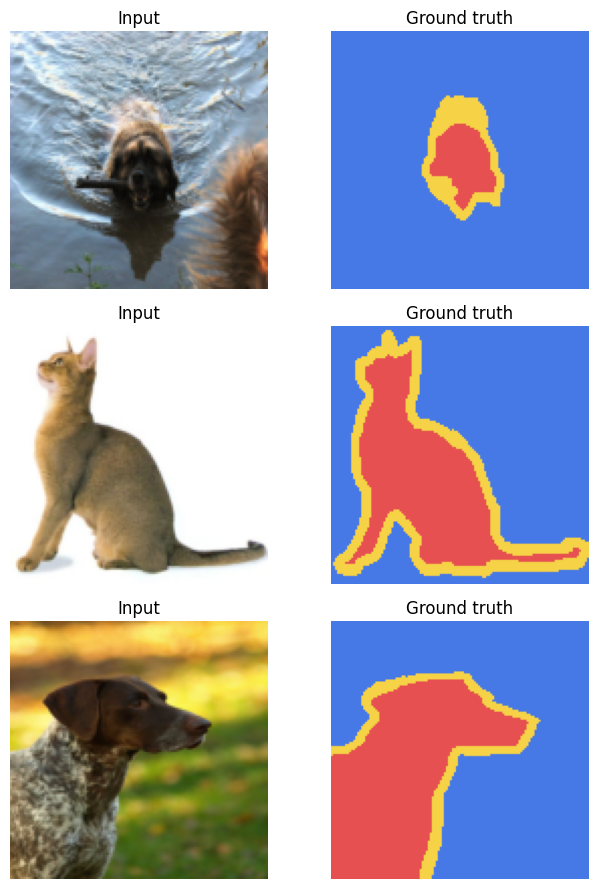

In [6]:
# =========================================================
# TRỰC QUAN HÓA DATASET
# =========================================================

# Oxford-IIIT Pet gồm nhiều giống chó và mèo.
# Trimap gồm ba lớp: pet, background và border.
CLASS_NAMES = ["pet", "background", "border"]

# Bảng màu chỉ dùng để hiển thị mask.
MASK_COLORS = np.array([
    [230, 80, 80],    # pet
    [70, 120, 230],   # background
    [245, 210, 70],   # border
], dtype=np.uint8)


def denormalize(image):
    # Khôi phục ảnh đã chuẩn hóa để hiển thị.
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (image.cpu() * std + mean).clamp(0, 1)


def colorize_mask(mask):
    # Đổi nhãn lớp thành màu RGB.
    return MASK_COLORS[mask.cpu().numpy()]


def show_dataset_samples(dataset, count=3):
    # Hiển thị ảnh đầu vào và mask thật.
    fig, axes = plt.subplots(count, 2, figsize=(7, 3 * count))

    for row in range(count):
        image, mask = dataset[row]

        axes[row, 0].imshow(denormalize(image).permute(1, 2, 0))
        axes[row, 0].set_title("Input")

        axes[row, 1].imshow(colorize_mask(mask))
        axes[row, 1].set_title("Ground truth")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()


# Hiển thị một vài mẫu huấn luyện.
show_dataset_samples(train_dataset)

## 4. Architecture overview

Encoder giảm dần spatial resolution để học feature ngữ nghĩa. Decoder tăng dần resolution. Ở mỗi tầng decoder, feature được nối theo chiều channel với feature encoder có cùng spatial size.

Luồng gợi ý: `input → encoder blocks → bottleneck → decoder blocks + skip features → 1×1 output head`.


## 5. TODO — Implement U-Net


In [7]:
# =========================================================
# TODO: XÂY DỰNG KHỐI DOUBLE CONV
# =========================================================

class DoubleConv(nn.Module):
    """Hai lớp Conv 3x3 liên tiếp, mỗi lớp theo sau bởi normalization và ReLU."""

    def __init__(self, in_channels, out_channels):
        super().__init__()

        # TODO: định nghĩa khối convolution.
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # TODO: trả về feature map sau khi đi qua khối DoubleConv.
        return self.block(x)

In [8]:
# =========================================================
# TODO: XÂY DỰNG KHỐI ENCODER
# =========================================================
class EncoderBlock(nn.Module):
    """Trả về skip feature và feature đã giảm kích thước."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        # TODO: kết hợp DoubleConv với giảm kích thước 2 lần.
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    def forward(self, x):
        # TODO: trả về feature cho skip và feature đã giảm kích thước.
        skip = self.conv(x)
        down = self.pool(skip)
        return skip, down

In [9]:
# =========================================================
# TODO: XÂY DỰNG KHỐI DECODER
# =========================================================
class DecoderBlock(nn.Module):
    """Tăng kích thước, nối skip feature rồi tinh chỉnh."""

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        # TODO: định nghĩa phép tăng kích thước và DoubleConv.
        # Sau khi nối, số kênh vào là out_channels + skip_channels.
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # Số kênh đầu vào cho DoubleConv là tổng số kênh upsampled + skip channels
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip=None):
        # TODO: tăng kích thước x, nối skip theo dim=1 rồi tinh chỉnh.
        x = self.up(x)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [10]:
# =========================================================
# TODO: XÂY DỰNG U-NET CÓ SKIP CONNECTION
# =========================================================
class UNet(nn.Module):
    """U-Net gọn nhẹ cho segmentation ba lớp."""

    def __init__(self, num_classes, base_channels=32):
        super().__init__()
        # TODO: định nghĩa encoder, bottleneck, decoder và đầu ra 1x1.
        # Encoder
        self.enc1 = EncoderBlock(3, base_channels)             # -> base_channels (32)
        self.enc2 = EncoderBlock(base_channels, base_channels * 2)     # -> base_channels * 2 (64)
        self.enc3 = EncoderBlock(base_channels * 2, base_channels * 4) # -> base_channels * 4 (128)

        # Bottleneck
        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8) # -> 256

        # Decoder (in_channels, skip_channels, out_channels)
        self.dec3 = DecoderBlock(base_channels * 8, base_channels * 4, base_channels * 4) # 256 -> 128
        self.dec2 = DecoderBlock(base_channels * 4, base_channels * 2, base_channels * 2) # 128 -> 64
        self.dec1 = DecoderBlock(base_channels * 2, base_channels, base_channels)         # 64 -> 32

        # Output head 1x1 conv
        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # TODO: nối các tầng encoder và decoder tương ứng bằng skip feature.
        # Encoder path
        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)

        # Bottleneck
        b = self.bottleneck(p3)

        # Decoder path kết hợp skip connection
        d3 = self.dec3(b, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)

        return self.out_conv(d1)

## 6. Quick shape test

Chạy cell này sau khi hoàn thành các TODO. Kết quả mong đợi: input `[B,3,H,W]`, output `[B,NUM_CLASSES,H,W]`.


In [11]:
set_seed(SEED)
model = UNet(num_classes=NUM_CLASSES)
x = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)
y = model(x)
print("Input:", x.shape)
print("Output:", y.shape)
assert y.shape == (2, NUM_CLASSES, IMAGE_SIZE, IMAGE_SIZE)


Input: torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 128, 128])


## 7. Training utilities

Validation cộng dồn intersection/union của từng class trên toàn epoch; mIoU chỉ được tính một lần sau batch cuối.


In [12]:
criterion = nn.CrossEntropyLoss()


@torch.no_grad()
def update_confusion_stats(preds, targets, num_classes, intersection_sum, union_sum):
    """Cộng dồn phần giao và hợp của từng lớp."""
    for class_id in range(num_classes):
        pred_class = preds == class_id
        target_class = targets == class_id
        intersection_sum[class_id] += (pred_class & target_class).sum().item()
        union_sum[class_id] += (pred_class | target_class).sum().item()


def compute_mean_iou(intersection_sum, union_sum):
    """Tính mIoU từ toàn bộ validation epoch."""
    valid = union_sum > 0
    if not valid.any():
        return float("nan")
    return (intersection_sum[valid] / union_sum[valid]).mean().item()


def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_items = 0
    intersection_sum = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    union_sum = torch.zeros(NUM_CLASSES, dtype=torch.float64)

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for images, masks in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            if is_training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, masks)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size
            if not is_training:
                preds = logits.argmax(dim=1)
                update_confusion_stats(
                    preds, masks, NUM_CLASSES, intersection_sum, union_sum
                )

    mean_loss = total_loss / total_items
    mean_iou = None if is_training else compute_mean_iou(intersection_sum, union_sum)
    return mean_loss, mean_iou


def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_iou": []}

    for epoch in range(1, num_epochs + 1):
        start = time.time()
        train_loss, _ = run_epoch(model, train_loader, optimizer)
        val_loss, val_iou = run_epoch(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
            f"mIoU {val_iou:.4f} | {time.time() - start:.1f}s"
        )
    return model, history


def plot_history(histories):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, history in histories.items():
        epochs = range(1, len(history["train_loss"]) + 1)
        axes[0].plot(epochs, history["train_loss"], marker="o", label=f"{label} train")
        axes[0].plot(epochs, history["val_loss"], marker="s", linestyle="--", label=f"{label} val")
        axes[1].plot(epochs, history["val_iou"], marker="o", label=label)
    axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy")
    axes[1].set(title="Validation mean IoU", xlabel="Epoch", ylabel="mIoU")
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()


## 8. Train U-Net

Re-seed giúp kết quả tái lập và giảm một phần nhiễu random; nó không làm hai kiến trúc khác nhau có cùng trọng số khởi tạo.


In [13]:
set_seed(SEED)
unet = UNet(num_classes=NUM_CLASSES)
unet, unet_history = train_model(unet, train_loader, val_loader)


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Epoch 01/10 | train loss 0.6692 | val loss 0.5338 | mIoU 0.5169 | 53.5s


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

...

  0%|          | 0/46 [00:00<?, ?it/s]

Epoch 09/10 | train loss 0.3120 | val loss 0.3126 | mIoU 0.6902 | 53.9s


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.2952 | val loss 0.3596 | mIoU 0.6581 | 51.4s


## 9. Baseline / Ablation — U-Net không Skip Connection

Giữ luồng encoder–bottleneck–decoder gần U-Net chính nhưng không chuyển encoder feature sang decoder.

**Gợi ý quan trọng:** vì không còn concatenate encoder feature, số input channel đi vào phần convolution của mỗi `DecoderBlock` giảm so với bản có skip (với thiết kế đối xứng thông thường là giảm một nửa). Hãy điều chỉnh channel cẩn thận; đây là lỗi shape thường gặp nhất.


In [14]:
# =========================================================
# TODO: XÂY DỰNG U-NET KHÔNG CÓ SKIP CONNECTION
# =========================================================
class UNetWithoutSkip(nn.Module):
    """Encoder-decoder không truyền feature từ encoder sang decoder."""

    def __init__(self, num_classes, base_channels=32):
        super().__init__()
        # TODO: định nghĩa encoder, bottleneck và decoder tuần tự,
        # cùng đầu ra 1x1; dùng skip_channels=0 hoặc cách tương đương.
        # Encoder
        self.enc1 = EncoderBlock(3, base_channels)
        self.enc2 = EncoderBlock(base_channels, base_channels * 2)
        self.enc3 = EncoderBlock(base_channels * 2, base_channels * 4)

        # Bottleneck
        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        # Decoder với skip_channels = 0
        self.dec3 = DecoderBlock(base_channels * 8, 0, base_channels * 4)
        self.dec2 = DecoderBlock(base_channels * 4, 0, base_channels * 2)
        self.dec1 = DecoderBlock(base_channels * 2, 0, base_channels)

        # Output head 1x1 conv
        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # TODO: chỉ giải mã từ feature sâu nhất, không nối skip.
        # Encoder path (chỉ lấy phần feature downsampled p, bỏ qua s)
        _, p1 = self.enc1(x)
        _, p2 = self.enc2(p1)
        _, p3 = self.enc3(p2)

        # Bottleneck
        b = self.bottleneck(p3)

        # Decoder path (không truyền skip)
        d3 = self.dec3(b)
        d2 = self.dec2(d3)
        d1 = self.dec1(d2)

        return self.out_conv(d1)


In [15]:
# Kiểm tra shape của mô hình đối chứng.
set_seed(SEED)
no_skip_shape_model = UNetWithoutSkip(num_classes=NUM_CLASSES)
x = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)
y = no_skip_shape_model(x)
print("Input:", x.shape)
print("Output:", y.shape)
assert y.shape == (2, NUM_CLASSES, IMAGE_SIZE, IMAGE_SIZE)


Input: torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 128, 128])


In [16]:
set_seed(SEED)
no_skip = UNetWithoutSkip(num_classes=NUM_CLASSES)
no_skip, no_skip_history = train_model(no_skip, train_loader, val_loader)


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Epoch 01/10 | train loss 0.6716 | val loss 0.5712 | mIoU 0.4802 | 50.7s


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

...

  0%|          | 0/46 [00:00<?, ?it/s]

Epoch 09/10 | train loss 0.3135 | val loss 0.3414 | mIoU 0.6697 | 51.1s


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.2981 | val loss 0.3634 | mIoU 0.6507 | 50.7s


## 10. Evaluation và comparison

Bảng dưới đây là placeholder. Sau khi hoàn thành TODO và train, cell kế tiếp sẽ tạo bảng bằng kết quả thật của bạn.

| Model | Validation Loss | Mean IoU |
|---|---:|---:|
| U-Net | ... | ... |
| U-Net without Skip | ... | ... |


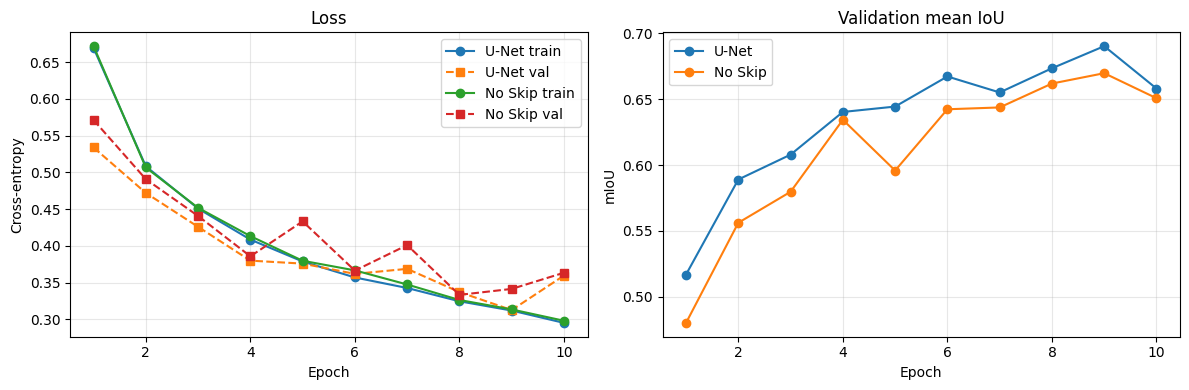

,Model,Validation Loss,Mean IoU
0,U-Net,0.3596,0.6581
1,U-Net without Skip,0.3634,0.6507


In [17]:
histories = {"U-Net": unet_history, "No Skip": no_skip_history}
plot_history(histories)

comparison = pd.DataFrame([
    {"Model": "U-Net", "Validation Loss": unet_history["val_loss"][-1],
     "Mean IoU": unet_history["val_iou"][-1]},
    {"Model": "U-Net without Skip", "Validation Loss": no_skip_history["val_loss"][-1],
     "Mean IoU": no_skip_history["val_iou"][-1]},
])
comparison.style.format({"Validation Loss": "{:.4f}", "Mean IoU": "{:.4f}"})


## 11. Visualization predictions


In [18]:
@torch.no_grad()
def predict_mask(model, image):
    model.eval()
    logits = model(image.unsqueeze(0).to(DEVICE))
    return logits.argmax(dim=1).squeeze(0).cpu()


def compare_predictions(models, dataset, model_names, count=3):
    columns = 2 + len(models)
    fig, axes = plt.subplots(count, columns, figsize=(4 * columns, 3.5 * count))
    for row in range(count):
        image, target = dataset[row]
        axes[row, 0].imshow(denormalize(image).permute(1, 2, 0))
        axes[row, 0].set_title("Input")
        axes[row, 1].imshow(colorize_mask(target))
        axes[row, 1].set_title("Ground truth")
        for col, (model, name) in enumerate(zip(models, model_names), start=2):
            axes[row, col].imshow(colorize_mask(predict_mask(model, image)))
            axes[row, col].set_title(name)
        for ax in axes[row]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


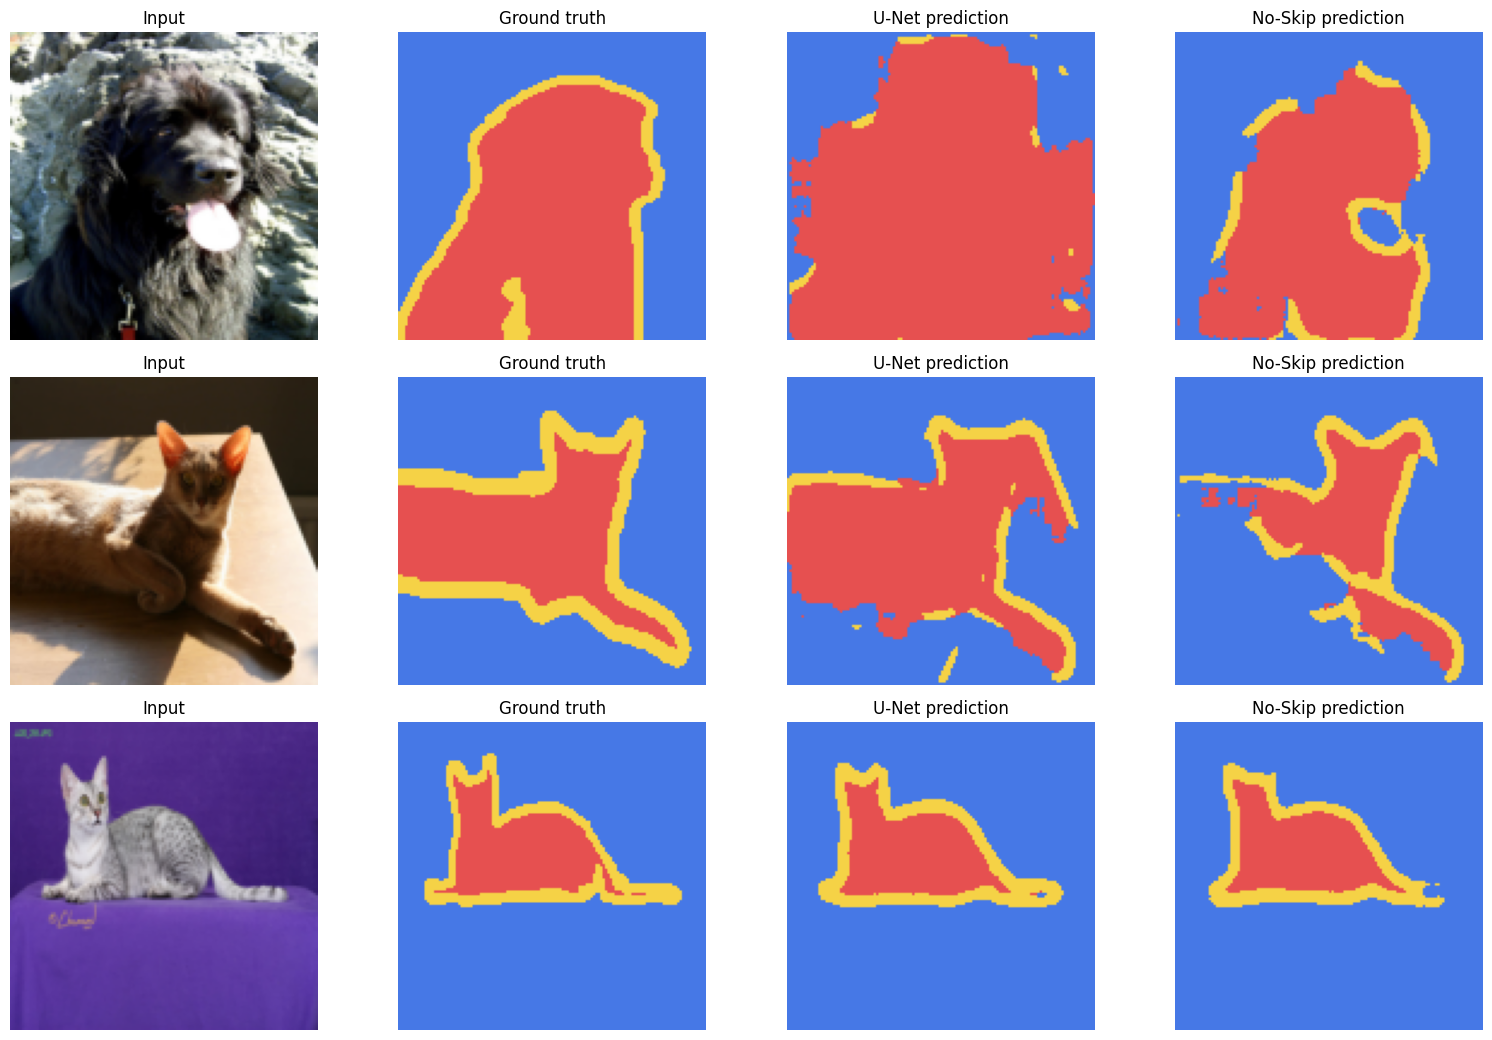

In [19]:
compare_predictions(
    [unet, no_skip], val_dataset,
    ["U-Net prediction", "No-Skip prediction"], count=3
)


## 12. Câu hỏi & kết luận

> So sánh kết quả định lượng và trực quan giữa U-Net có và không có Skip Connection. Từ đó nhận xét Skip Connection ảnh hưởng như thế nào đến quá trình học và khả năng phục hồi thông tin không gian, đặc biệt ở vùng biên và các chi tiết nhỏ?

**Trả lời của bạn:**

...
